# 03 · Comportamiento en el tiempo

**Preguntas:**
- ¿Qué ciclos tienen los datos (diario, semanal, anual)?
- ¿Cuánto "recuerda" cada parámetro su valor anterior? Es decir, ¿qué tan predecible es a 24 h?
- ¿Cuánto tarda un cambio en la fuente en llegar a cada sensor?
- ¿Qué tan bien pronostican a 24 h los métodos más simples? Eso define la línea base que el modelo
  tiene que superar.

Se trabaja con **promedios horarios** de las lecturas válidas (`src/calidad.py`). Así se reduce el
ruido de medición, que a 15 min es comparable con los cambios que se quieren ver. Para los ciclos se
usa solo la **operación normal**, sin evento visible en el sensor.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src import carga, calidad
from src.graficos import estilo, guardar, COLORES, GRIS

estilo()
pd.set_option("display.precision", 3)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

t15 = calidad.lecturas_validas(carga.cargar_todo())
S = carga.sensores(t15)
CAL = ["CL2", "TURB", "PH", "TEMP"]
ETIQ = {"CL2": "Cloro libre (mg/L)", "TEMP": "Temperatura (°C)", "TURB": "Turbidez (UNT)",
        "PH": "pH", "P": "Presión (m)", "Q_R1": "Caudal de la fuente (L/s)"}

# promedios horarios; el evento se toma como el máximo de la hora
h = t15.drop(columns="particion").resample("1h").mean()
evento = t15[[f"evento_{n}" for n in S]].resample("1h").max()
particion = t15["particion"].resample("1h").first()
h["lluvia_mm"] = t15["lluvia_mm_h"].resample("1h").mean()          # mm en la hora

def normal(p, n):
    # serie horaria de un sensor, solo en operación normal
    return h[f"{p}_{n}"].where(evento[f"evento_{n}"] == 0)

# sensores representativos: salida de la fuente, uno intermedio y el del extremo
REPRES = {"J280": "salida de la fuente", "J224": "intermedio", "J144": "extremo de la red"}
print(f"{len(h):,} horas · {len(S)} sensores")

17,520 horas · 21 sensores


## 1. Los dos años completos

Promedios diarios, con la lluvia diaria arriba. Se ve el año completo dos veces: la época seca
(diciembre a abril) y la lluviosa (mayo a noviembre).

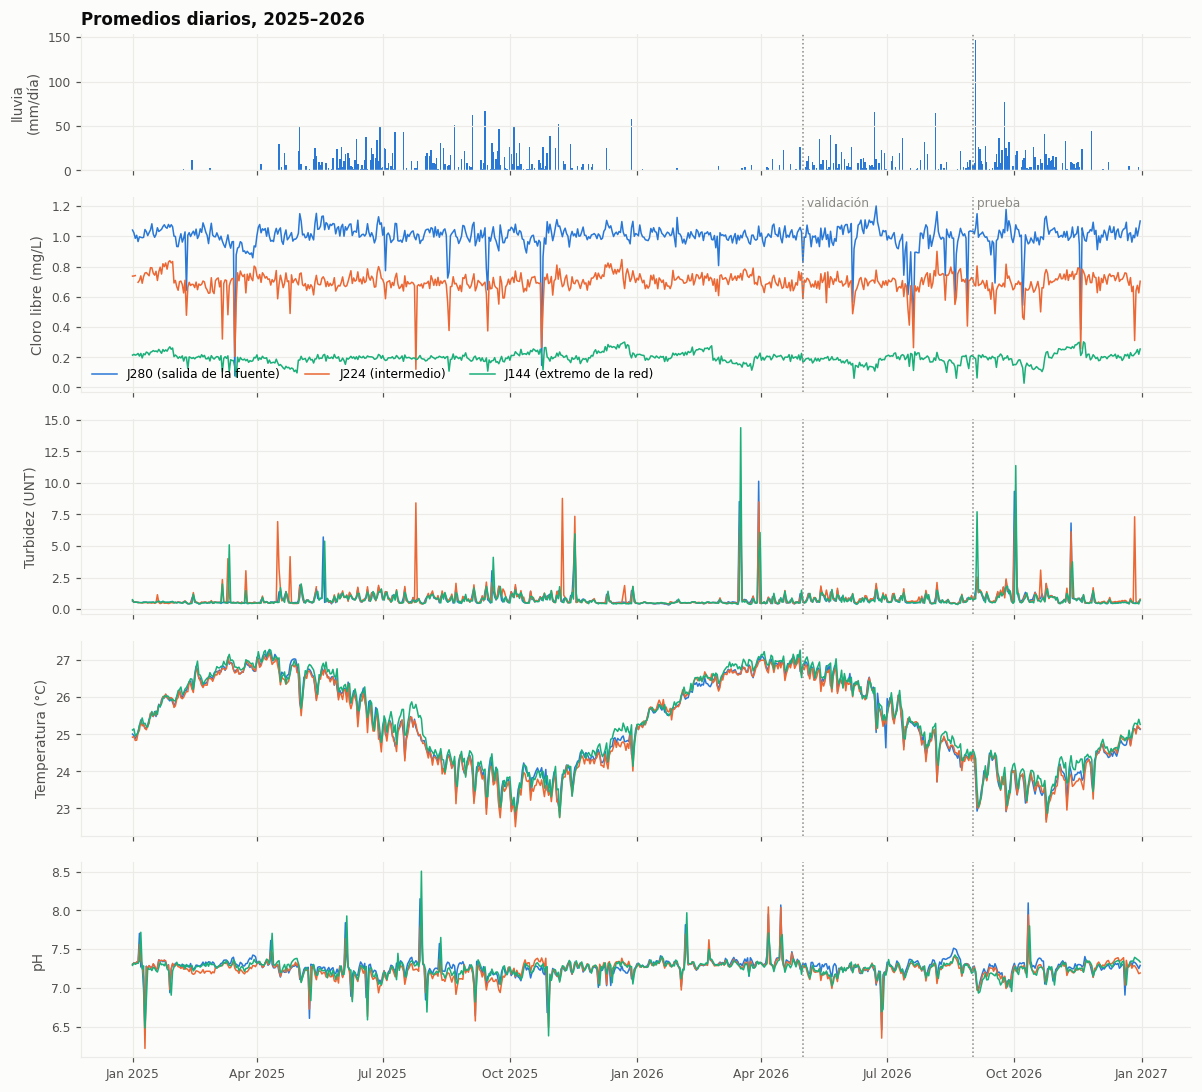

In [2]:
dia = h.resample("1D").mean()
lluvia_dia = h["lluvia_mm"].resample("1D").sum()

fig, axes = plt.subplots(5, 1, figsize=(11, 10), sharex=True,
                         gridspec_kw={"height_ratios": [0.7, 1, 1, 1, 1]})
axes[0].bar(lluvia_dia.index, lluvia_dia, width=1, color=COLORES[0])
axes[0].set_ylabel("lluvia\n(mm/día)")
axes[0].set_title("Promedios diarios, 2025–2026")
for ax, p in zip(axes[1:], ["CL2", "TURB", "TEMP", "PH"]):
    for k, (n, nombre) in enumerate(REPRES.items()):
        ax.plot(dia[f"{p}_{n}"], color=COLORES[k], lw=1, label=f"{n} ({nombre})")
    ax.set_ylabel(ETIQ[p])
for ax in axes:
    for lim in ["2026-05-01", "2026-09-01"]:
        ax.axvline(pd.Timestamp(lim), color=GRIS, lw=1, ls=":")
axes[1].legend(ncol=3, loc="lower left")
axes[1].text(pd.Timestamp("2026-05-01"), axes[1].get_ylim()[1], " validación", color=GRIS, fontsize=8, va="top")
axes[1].text(pd.Timestamp("2026-09-01"), axes[1].get_ylim()[1], " prueba", color=GRIS, fontsize=8, va="top")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.tight_layout()
guardar(fig, "03_serie_completa"); plt.show()

## 2. Ciclo diario

Valor típico de cada hora del día en operación normal: mediana, y rango 25–75 % en caudal, presión
y cloro. El consumo de agua
tiene un ciclo diario marcado, y con él cambian el caudal, la presión y el tiempo que el agua pasa en
la red.

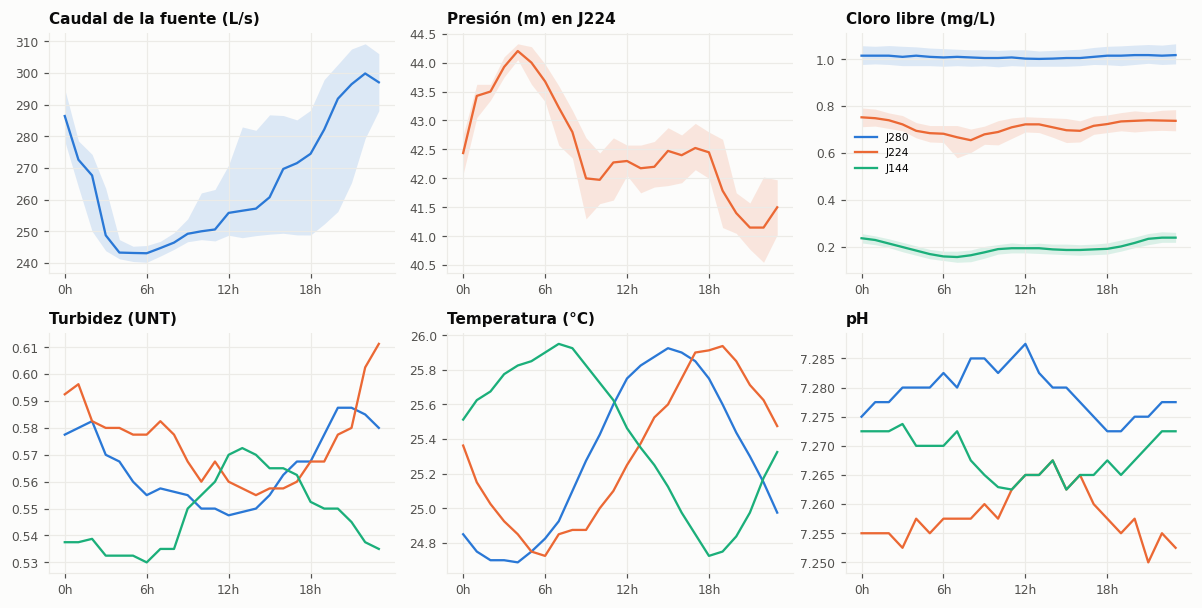

In [3]:
def perfil(serie):
    g = serie.groupby(serie.index.hour)
    return g.median(), g.quantile(0.25), g.quantile(0.75)

fig, axes = plt.subplots(2, 3, figsize=(11, 5.6))
paneles = [("Q_R1", None), ("P", "J224"), ("CL2", None), ("TURB", None), ("TEMP", None), ("PH", None)]
for ax, (p, solo) in zip(axes.ravel(), paneles):
    if p == "Q_R1":
        m, a, b = perfil(h["Q_R1"])
        ax.plot(m.index, m, color=COLORES[0]); ax.fill_between(m.index, a, b, color=COLORES[0], alpha=0.15, lw=0)
    else:
        for k, (n, nombre) in enumerate(REPRES.items()):
            if solo and n != solo:
                continue
            m, a, b = perfil(normal(p, n))
            ax.plot(m.index, m, color=COLORES[k], label=n)
            if p in ("CL2", "P"):              # en los demás las bandas se superponen; se omiten
                ax.fill_between(m.index, a, b, color=COLORES[k], alpha=0.15, lw=0)
    ax.set_title(ETIQ[p] + (f" en {solo}" if solo else ""), fontsize=10)
    ax.set_xticks(range(0, 24, 6)); ax.set_xticklabels([f"{x}h" for x in range(0, 24, 6)])
axes[0, 2].legend(fontsize=7)
fig.tight_layout()
guardar(fig, "03_ciclo_diario"); plt.show()

In [4]:
amplitud = {}
for p in CAL + ["P"]:
    filas = []
    for n in S:
        m = normal(p, n).groupby(h.index.hour).median()
        filas.append(m.max() - m.min())
    amplitud[ETIQ[p]] = {"amplitud mediana del ciclo diario": np.median(filas),
                         "mínima": np.min(filas), "máxima": np.max(filas)}
amplitud["Caudal de la fuente (L/s)"] = {"amplitud mediana del ciclo diario": float(np.ptp(h["Q_R1"].groupby(h.index.hour).median()))}
pd.DataFrame(amplitud).T

,amplitud mediana del ciclo diario,mínima,máxima
Cloro libre (mg/L),0.100,0.016,0.327
Turbidez (UNT),0.044,0.027,0.067
pH,0.014,0.010,0.020
Temperatura (°C),1.200,0.887,1.263
Presión (m),17.700,0.025,37.975
Caudal de la fuente (L/s),56.812,NaN,NaN


## 3. Ciclo semanal

¿Cambia el consumo según el día de la semana? Mapa de calor del caudal de la fuente por día y hora.

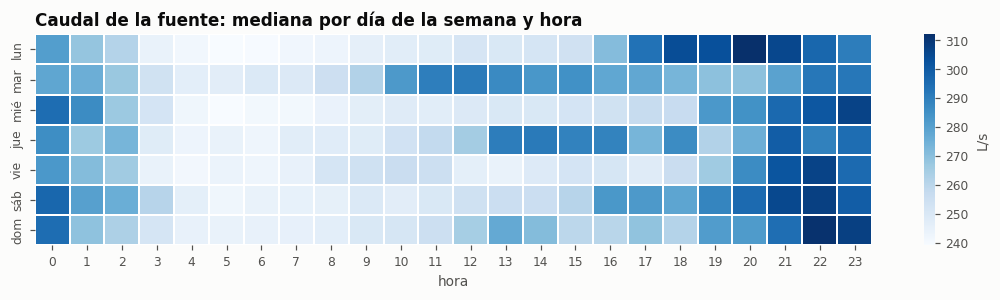

Caudal medio por día (L/s): {'lun': 265.70001220703125, 'mar': 269.8999938964844, 'mié': 262.29998779296875, 'jue': 266.6000061035156, 'vie': 262.5, 'sáb': 265.70001220703125, 'dom': 266.3999938964844}


In [5]:
dias = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]
semana = h["Q_R1"].groupby([h.index.dayofweek, h.index.hour]).median().unstack()
semana.index = dias
fig, ax = plt.subplots(figsize=(10, 2.8))
sns.heatmap(semana, cmap="Blues", ax=ax, cbar_kws={"label": "L/s"}, linewidths=0.3, linecolor="white")
ax.set_title("Caudal de la fuente: mediana por día de la semana y hora"); ax.set_xlabel("hora"); ax.set_ylabel("")
ax.grid(False)
fig.tight_layout()
guardar(fig, "03_ciclo_semanal"); plt.show()

por_dia = h["Q_R1"].groupby(h.index.dayofweek).mean()
print("Caudal medio por día (L/s):", dict(zip(dias, por_dia.round(1))))

## 4. Ciclo anual

Mediana mensual en operación normal, con la lluvia del mes. Junta los dos años.

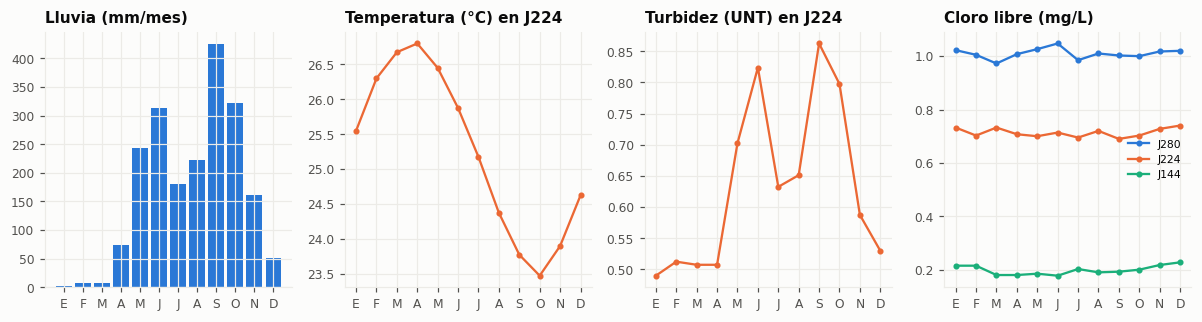

In [6]:
meses = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]
lluvia_mes = h["lluvia_mm"].groupby([h.index.year, h.index.month]).sum().groupby(level=1).mean()
fig, axes = plt.subplots(1, 4, figsize=(11, 3))
axes[0].bar(range(1, 13), lluvia_mes, color=COLORES[0])
axes[0].set_title("Lluvia (mm/mes)", fontsize=10)
for ax, p in zip(axes[1:], ["TEMP", "TURB", "CL2"]):
    for k, (n, nombre) in enumerate(REPRES.items()):
        if p != "CL2" and n != "J224":
            continue
        s = normal(p, n)
        ax.plot(range(1, 13), s.groupby(s.index.month).median(), "o-", ms=3, color=COLORES[k], label=n)
    ax.set_title(ETIQ[p] + ("" if p == "CL2" else " en J224"), fontsize=10)
for ax in axes:
    ax.set_xticks(range(1, 13)); ax.set_xticklabels([m[0].upper() for m in meses])
axes[3].legend(fontsize=7)
fig.tight_layout()
guardar(fig, "03_ciclo_anual"); plt.show()

## 5. Memoria de cada parámetro (autocorrelación)

La autocorrelación a un retraso de *k* horas dice cuánto se parece el valor de ahora al de hace *k*
horas. Un valor cercano a 1 a las 24 h significa que lo de ayer es una buena pista para lo de
mañana. Se calcula por sensor y se muestra la mediana de los 21, primero con todas las horas y
luego solo con la operación normal: los eventos son cambios grandes y poco frecuentes que dominan
la variación total.

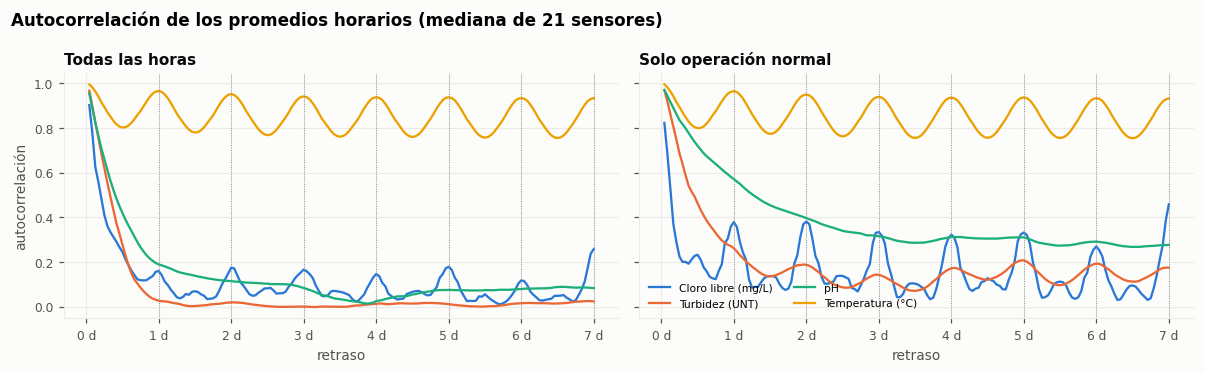

1 h    6 h   12 h   24 h   48 h  168 h
todas las horas  CL2   0.902  0.410  0.244  0.160  0.175  0.258
                 TURB  0.966  0.620  0.277  0.027  0.020  0.024
                 PH    0.954  0.660  0.419  0.190  0.114  0.083
                 TEMP  0.995  0.893  0.801  0.964  0.951  0.933
operación normal CL2   0.822  0.224  0.233  0.379  0.381  0.458
                 TURB  0.969  0.686  0.463  0.262  0.188  0.175
                 PH    0.969  0.834  0.720  0.571  0.396  0.276
                 TEMP  0.995  0.893  0.799  0.964  0.949  0.931

In [7]:
retrasos = np.arange(1, 24 * 7 + 1)

def autocorrelacion(serie_de):
    acf = {}
    for p in CAL:
        por_sensor = [[serie_de(p, n).autocorr(k) for k in retrasos] for n in S]
        acf[p] = np.nanmedian(np.array(por_sensor), axis=0)
    return pd.DataFrame(acf, index=retrasos)

acf_todo = autocorrelacion(lambda p, n: h[f"{p}_{n}"])
acf_normal = autocorrelacion(normal)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, (nombre, acf) in zip(axes, [("Todas las horas", acf_todo), ("Solo operación normal", acf_normal)]):
    for k, p in enumerate(CAL):
        ax.plot(acf.index, acf[p], color=COLORES[k], label=ETIQ[p])
    for d in range(1, 8):
        ax.axvline(24 * d, color=GRIS, lw=0.6, ls=":")
    ax.set_xticks(range(0, 24 * 7 + 1, 24)); ax.set_xticklabels([f"{d} d" for d in range(8)])
    ax.set_xlabel("retraso"); ax.set_title(nombre, fontsize=10)
axes[0].set_ylabel("autocorrelación")
axes[1].legend(ncol=2, loc="lower left", fontsize=7)
fig.suptitle("Autocorrelación de los promedios horarios (mediana de 21 sensores)", x=0.01, ha="left",
             fontsize=11, fontweight="bold")
fig.tight_layout()
guardar(fig, "03_autocorrelacion"); plt.show()

pd.concat({"todas las horas": acf_todo, "operación normal": acf_normal}, axis=1).loc[[1, 6, 12, 24, 48, 168]]     .rename(index=lambda k: f"{k} h").T

## 6. Tiempo de viaje desde la fuente

Un cambio de turbidez en la fuente (J280) llega a cada sensor con un retraso que depende del
recorrido del agua. Ese retraso se estima con la correlación cruzada entre los cambios horarios de
turbidez en J280 y en cada sensor: el retraso con la correlación más alta es el tiempo de viaje
típico.

In [8]:
fuente = h["TURB_J280"].diff()
viaje = {}
for n in S:
    destino = h[f"TURB_{n}"].diff()
    cc = np.array([fuente.corr(destino.shift(-k)) for k in range(0, 49)])
    viaje[n] = {"tiempo de viaje (h)": int(np.nanargmax(cc)), "correlación": np.nanmax(cc),
                "cloro mediano (mg/L)": np.nanmedian(h[f"CL2_{n}"])}
viaje = pd.DataFrame(viaje).T.sort_values("tiempo de viaje (h)")
viaje.T

,J280,J439,J1058,J224,J345,J1153,J360,J69,J101,J237,J27,J284,J150,J334,J167,J296,J379,N6,J123,J189,J144
tiempo de viaje (h),0.000,1.000,2.000,3.000,3.000,3.000,3.000,3.000,3.000,3.000,3.000,3.000,3.000,3.000,4.000,4.000,5.000,5.000,8.000,9.000,16.000
correlación,1.000,0.785,0.751,0.436,0.389,0.752,0.698,0.502,0.821,0.656,0.468,0.287,0.428,0.450,0.671,0.261,0.419,0.519,0.265,0.636,0.428
cloro mediano (mg/L),1.008,0.873,0.738,0.710,0.692,0.783,0.790,0.728,0.750,0.762,0.630,0.635,0.733,0.803,0.757,0.613,0.663,0.438,0.387,0.455,0.197


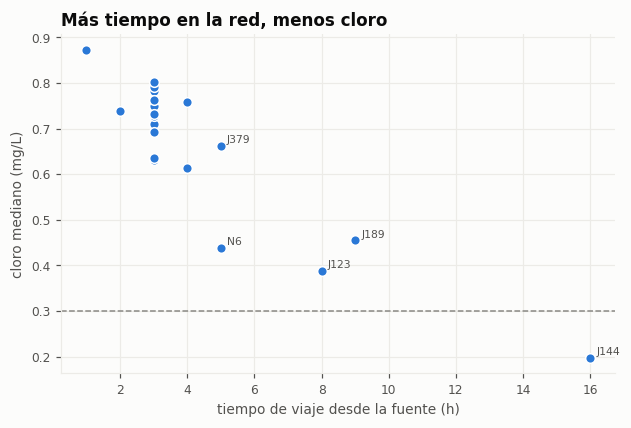

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4))
v = viaje.drop("J280")
ax.scatter(v["tiempo de viaje (h)"], v["cloro mediano (mg/L)"], s=40, color=COLORES[0], zorder=3,
           edgecolor="white", linewidth=1)
for n, fila in v.iterrows():
    if fila["tiempo de viaje (h)"] >= 5 or fila["cloro mediano (mg/L)"] < 0.5:
        ax.annotate(n, (fila["tiempo de viaje (h)"], fila["cloro mediano (mg/L)"]), fontsize=7,
                    xytext=(4, 2), textcoords="offset points", color="#52514e")
ax.axhline(0.3, color=GRIS, ls="--", lw=1)
ax.set_xlabel("tiempo de viaje desde la fuente (h)"); ax.set_ylabel("cloro mediano (mg/L)")
ax.set_title("Más tiempo en la red, menos cloro")
guardar(fig, "03_tiempo_viaje"); plt.show()

## 7. Línea base: ¿qué tan bien pronostican los métodos más simples?

Antes de entrenar un modelo hay que saber cuánto se logra **sin modelo**. Se prueban dos métodos
ingenuos para cada horizonte de 1 a 24 h:

- **persistencia**: "dentro de *H* horas el valor será igual al de ahora";
- **misma hora de ayer**: "el valor será igual al de hace 24 h a esa misma hora del día"
  (aprovecha el ciclo diario).

Un pronóstico se cuenta como **acertado** si queda dentro de la tolerancia del valor observado
(promedio horario). Las tolerancias son las de la meta del proyecto (`src/metas.py`):

| Parámetro | Tolerancia | Criterio |
|---|---|---|
| Cloro libre | ± 0,1 mg/L | ~2 veces el ruido del sensor; 1/7 del rango de la norma (0,3–1,0) |
| Turbidez | ± 20 % del valor, mínimo ± 0,2 UNT | se adapta al nivel (± 0,2 en 0,5 UNT; ± 2 en 10 UNT), como la precisión de un turbidímetro |
| pH | ± 0,1 | ~3 veces el ruido del sensor |
| Temperatura | ± 0,5 °C | solo se reporta: no tiene límite en la norma |

**Meta del proyecto:** al menos el 80 % de los pronósticos a 24 h dentro de la tolerancia en cloro,
turbidez y pH en operación normal, y mejor que "misma hora de ayer" en cada parámetro. El acierto
durante eventos se reporta por separado.

Se evalúa en el periodo de **validación**. La prueba se reserva para la evaluación final del modelo,
así que no se usa para tomar decisiones.

In [10]:
from src import metas
es_val = (particion == "validacion").values
horizontes = np.arange(1, 25)

def evaluar(metodo, p, H, en_evento):
    aciertos, errores = [], []
    for n in S:
        y = h[f"{p}_{n}"]
        pred = y.shift(H) if metodo == "persistencia" else y.shift(24)
        m = es_val & ((evento[f"evento_{n}"] > 0) if en_evento else (evento[f"evento_{n}"] == 0)).values
        e = (y - pred)[m].dropna()
        obs = y[m][e.index]
        aciertos.append(np.abs(e.values) <= metas.tolerancia(p, obs.values)); errores.append(e.abs().values)
    return 100 * np.concatenate(aciertos).mean(), np.concatenate(errores).mean()

filas = []
for p in CAL:
    for H in horizontes:
        for metodo in ["persistencia", "misma hora de ayer"]:
            for en_evento in [False, True]:
                acierto, mae = evaluar(metodo, p, H, en_evento)
                filas.append({"parámetro": p, "horizonte": H, "método": metodo,
                              "condición": "evento" if en_evento else "normal",
                              "% dentro de tolerancia": acierto, "error absoluto medio": mae})
base = pd.DataFrame(filas)

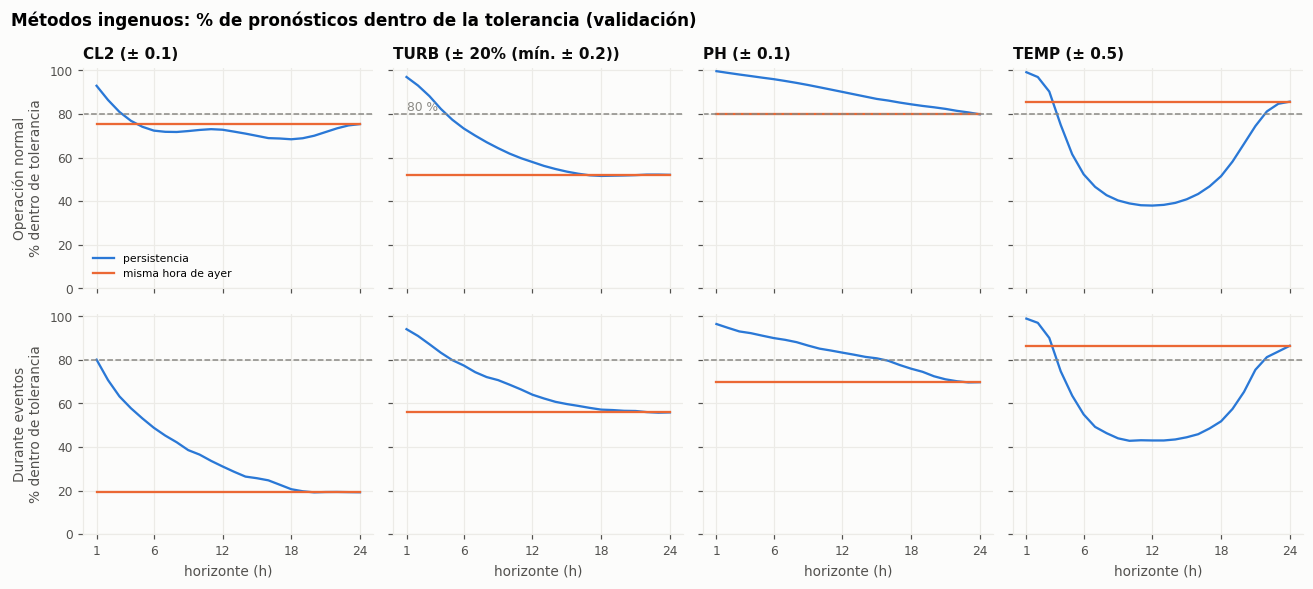

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(12, 5.4), sharex=True, sharey=True)
for j, p in enumerate(CAL):
    for i, cond in enumerate(["normal", "evento"]):
        ax = axes[i, j]
        for k, metodo in enumerate(["persistencia", "misma hora de ayer"]):
            d = base[(base["parámetro"] == p) & (base["método"] == metodo) & (base["condición"] == cond)]
            ax.plot(d["horizonte"], d["% dentro de tolerancia"], color=COLORES[k], label=metodo)
        ax.axhline(80, color=GRIS, ls="--", lw=1)
        ax.set_ylim(0, 101)
        if i == 0:
            ax.set_title(f"{p} ({metas.texto_tolerancia(p)})", fontsize=10)
        if j == 0:
            ax.set_ylabel(f"{'Operación normal' if cond == 'normal' else 'Durante eventos'}\n% dentro de tolerancia")
        if i == 1:
            ax.set_xlabel("horizonte (h)"); ax.set_xticks([1, 6, 12, 18, 24])
axes[0, 0].legend(loc="lower left", fontsize=7)
axes[0, 1].text(1, 80, "80 %", color=GRIS, fontsize=8, ha="left", va="bottom")
fig.suptitle("Métodos ingenuos: % de pronósticos dentro de la tolerancia (validación)", x=0.01, ha="left",
             fontsize=11, fontweight="bold")
fig.tight_layout()
guardar(fig, "03_linea_base"); plt.show()

In [12]:
resumen = base[base["horizonte"].isin([6, 12, 24])].pivot_table(
    index=["condición", "método"], columns=["parámetro", "horizonte"], values="% dentro de tolerancia")[CAL]
resumen.round(1)

parámetro                      CL2              TURB                PH              TEMP            
horizonte                       6     12    24    6     12    24    6     12    24    6     12    24
condición método                                                                                    
evento    misma hora de ayer  19.2  19.2  19.2  55.9  55.9  55.9  69.7  69.7  69.7  86.5  86.5  86.5
          persistencia        48.8  31.1  19.2  77.4  64.0  55.9  90.0  83.3  69.7  55.0  43.0  86.5
normal    misma hora de ayer  75.4  75.4  75.4  52.1  52.1  52.1  79.9  79.9  79.9  85.7  85.7  85.7
          persistencia        72.4  72.8  75.4  73.3  57.9  52.1  96.0  90.1  79.9  52.3  38.0  85.7

## 8. Conclusiones e implicaciones para el modelo

**Lo que dicen los datos**

1. **Hay un ciclo diario fuerte, que viene del consumo.**
   - El caudal de la fuente va de unos 243 L/s en la madrugada a 300 L/s en la noche.
   - La presión se mueve al revés: es máxima de madrugada, cuando casi nadie consume.
   - El cloro baja en la madrugada, porque con poco consumo el agua pasa más tiempo en la red; la
     amplitud mediana es de 0,10 mg/L, igual a la tolerancia de la meta.
   - La temperatura oscila 1,2 °C en el día, con la hora del máximo desplazada de un sensor a otro
     según el tiempo de viaje.
2. **No hay ciclo semanal.** El caudal es prácticamente igual todos los días de la semana (262–270
   L/s): el día de la semana no aporta información al modelo.
3. **El ciclo anual lo marca la lluvia.**
   - La temperatura del agua es máxima en abril (26,8 °C) y mínima en octubre (23,5 °C), en la
     parte más lluviosa del año.
   - La turbidez sube de 0,5 UNT en la época seca a 0,8–0,9 UNT en los meses más lluviosos.
   - El cloro casi no cambia con la época.
4. **Cada parámetro tiene una "memoria" distinta.**
   - La temperatura se repite casi igual de un día a otro: su autocorrelación a 24 h es 0,96.
   - El pH y la turbidez son muy persistentes de una hora a la siguiente, pero a las 24 h ya
     recuerdan poco (0,57 y 0,26 en operación normal).
   - El cloro tiene la memoria más corta (0,38 a 24 h): su variación de hora a hora es comparable
     con el ruido del sensor.
5. **El agua tarda de 1 a 16 horas en llegar de la fuente a los sensores.** La mayoría está a unas
   3 h; J123, J189 y J144 están a 8, 9 y 16 h. Son los de menos cloro: **más tiempo en la red,
   menos cloro**. Un cambio en la fuente se ve en J144 hasta 16 h después, así que para esos
   sensores parte del "futuro" ya está en los datos de la fuente.
6. **La línea base a 24 h.** Con las tolerancias de la meta, repetir el valor de la misma hora de
   ayer acierta, en operación normal, el 75 % en cloro, el 52 % en turbidez y el 80 % en pH (y el
   86 % en temperatura). Ninguno de los tres parámetros de la meta la supera con claridad sin
   modelo: el 80 % exige que el modelo aporte.
7. **Los métodos ingenuos fallan durante los eventos.** A 24 h aciertan solo el 19 % en cloro, el
   56 % en turbidez y el 70 % en pH. Un evento es justamente un cambio que no estaba ayer.

**Qué implica para el modelo (y para la meta del 80 %)**

- **La meta tiene una referencia.** El modelo tiene que llegar al 80 % y además superar la línea
  base de este notebook: 75 % en cloro, 52 % en turbidez y 80 % en pH. Con tolerancias más
  amplias el método sin modelo ya cumpliría el 80 % (con ± 0,12 mg/L en cloro, ± 0,6 UNT en
  turbidez), y la meta no demostraría nada.
- **Lo que más se espera del modelo está en los eventos.** Ahí la línea base solo logra el 19 % en
  cloro; ese resultado se reporta aparte.
- **Variables de entrada que valen la pena:** la hora del día, porque hay ciclo diario fuerte.
  También los valores de las últimas 24 h y de la misma hora de ayer. El día de la semana no aporta.
- **Usar los sensores cercanos a la fuente para pronosticar los lejanos.** Con retrasos de hasta
  16 h, la lectura de J280 de hoy explica buena parte de lo que pasará en J144 mañana.
- **La turbidez a 24 h depende de lluvia que todavía no ha caído.** Su memoria se pierde en
  menos de un día; el pronóstico de lluvia es la información que más le puede sumar.
- **El cloro es el parámetro más difícil:** memoria corta, ciclo diario del mismo tamaño que la
  tolerancia y eventos que lo hacen caer. Es donde hay que enfocar el esfuerzo del modelo.